# Notebook 3 — Flow-Based Feature Engineering

Raw Wireshark packets are not suitable for ML directly — a single attack can look normal at the
packet level. Instead, we group packets into **flows** (same source, destination, protocol within
a time window) and extract **statistical features** over each flow.

This makes the model generalise to real-world captures where background traffic is present.

**All feature extraction logic lives in `utils/feature_engineering.py`** so that Notebook 5
(inference) uses the exact same code — preventing train/inference skew.

In [1]:
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Make sure utils/ is importable regardless of working directory
sys.path.insert(0, str(Path('.').resolve()))

from utils.feature_engineering import (
    preprocess_packets,
    extract_flow_features,
    FEATURE_COLS,
    TIME_WINDOW_SECONDS,
)

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

DATA_DIR = Path('data')
print(f'Time window for flow grouping: {TIME_WINDOW_SECONDS}s')
print(f'Feature columns ({len(FEATURE_COLS)}): {FEATURE_COLS}')

Time window for flow grouping: 5s
Feature columns (18): ['packet_count', 'avg_length', 'std_length', 'min_length', 'max_length', 'avg_iat', 'std_iat', 'duration', 'bytes_per_second', 'packets_per_second', 'syn_count', 'ack_count', 'fin_count', 'rst_count', 'http_request_count', 'http_response_count', 'unique_dst_ports', 'protocol_encoded']


## 1. Load raw combined data

In [2]:
raw = pd.read_parquet(DATA_DIR / 'raw_combined.parquet')
print(f'Raw data: {raw.shape[0]:,} rows x {raw.shape[1]} columns')
print('Labels:', raw['label'].value_counts().to_dict())

Raw data: 333,192 rows x 9 columns
Labels: {'Exploit': 122924, 'Benign': 75236, 'Flood': 58672, 'Brute_Force': 39102, 'Probe': 23258, 'Malware': 14000}


## 2. Preprocess packets

Clean types, parse TCP flags and HTTP keywords from the `Info` column.

In [3]:
print('Preprocessing packets...')
preprocessed = preprocess_packets(raw)

print(f'After preprocessing: {preprocessed.shape[0]:,} rows x {preprocessed.shape[1]} columns')
print('\nSample of parsed flag columns:')
flag_cols = ['info', 'syn', 'ack', 'fin', 'rst', 'http_req', 'http_resp', 'dst_port']
preprocessed[flag_cols].head(10)

Preprocessing packets...
After preprocessing: 333,192 rows x 16 columns

Sample of parsed flag columns:


,info,syn,ack,fin,rst,http_req,http_resp,dst_port
0,M-SEARCH * HTTP/1.1,0,0,0,0,0,0,NaN
1,"Application Data, Application Data",0,0,0,0,0,0,NaN
2,60888 > 443 [ACK] Seq=1505 Ack=4066 Win=6361...,0,1,0,0,0,0,443.0
3,"Protected Payload (KP0), DCID=d90bfc3231755645",0,0,0,0,0,0,NaN
4,Application Data,0,0,0,0,0,0,NaN
5,60888 > 443 [ACK] Seq=1505 Ack=4618 Win=6310...,0,1,0,0,0,0,443.0
6,Standard query 0xd535 A gae2-spclient.spotify.com,0,0,0,0,0,0,NaN
7,Standard query 0x4629 AAAA gae2-spclient.spoti...,0,0,0,0,0,0,NaN
8,"Protected Payload (KP0), DCID=eebeed2a9910317d",0,0,0,0,0,0,NaN
9,Standard query 0xe8d0 A api-partner.spotify.com,0,0,0,0,0,0,NaN


In [4]:
# Quick check: flag counts per class
flag_summary = preprocessed.groupby('label')[['syn','ack','fin','rst','http_req','http_resp']].sum()
print('TCP/HTTP flag totals per class:')
print(flag_summary.to_string())

TCP/HTTP flag totals per class:
              syn    ack  fin  rst  http_req  http_resp
label                                                  
Benign        320  14080    0   90        24          0
Brute_Force  2662  11290    0   18         0          0
Exploit      8460  46600    0    0       414        422
Flood        4734   9314    0    0      1438        484
Malware       204   6128    0  894       142         68
Probe        4088   7294    0  324       126        122


## 3. Extract flow-level features

Group packets into flows using a `5-second` sliding time window keyed on
`(Source, Destination, Protocol)`. Then compute statistical aggregates over each flow.

In [5]:
print('Extracting flow features — this may take a few minutes on large datasets...')

# Process each source file separately to avoid cross-capture flow leakage
flow_dfs = []

for src_file, grp in preprocessed.groupby('src_file'):
    label = grp['label'].iloc[0]
    flows = extract_flow_features(grp, label_col='label')
    flows['src_file'] = src_file
    flow_dfs.append(flows)
    print(f'  {src_file:60s}  {len(grp):>7,} pkts → {len(flows):>5,} flows  [{label}]')

features = pd.concat(flow_dfs, ignore_index=True)
print(f'\nTotal flows extracted: {len(features):,}')

Extracting flow features — this may take a few minutes on large datasets...
    Dropped 80 micro-flows (< 5 packets)
  benign\benign-1.csv                                             5,000 pkts →    87 flows  [Benign]
    Dropped 918 micro-flows (< 5 packets)
  benign\benign-2.csv                                             5,000 pkts →   315 flows  [Benign]
    Dropped 995 micro-flows (< 5 packets)
  benign\benign-3.csv                                             5,000 pkts →   312 flows  [Benign]
    Dropped 872 micro-flows (< 5 packets)
  benign\benign-4.csv                                             5,000 pkts →   273 flows  [Benign]
    Dropped 412 micro-flows (< 5 packets)
  benign\benign-5.csv                                             2,084 pkts →   133 flows  [Benign]
  brute_force\SMB_brute_force-2.csv                               7,595 pkts →   120 flows  [Brute_Force]
    Dropped 1 micro-flows (< 5 packets)
  brute_force\SMB_brute_force.csv                               

## 4. Validate feature DataFrame

In [6]:
print('Feature DataFrame shape:', features.shape)
print('\nColumns:', features.columns.tolist())
print('\nLabel distribution (flows):')
print(features['label'].value_counts().to_string())

Feature DataFrame shape: (4782, 21)

Columns: ['flow_id', 'packet_count', 'avg_length', 'std_length', 'min_length', 'max_length', 'avg_iat', 'std_iat', 'duration', 'bytes_per_second', 'packets_per_second', 'syn_count', 'ack_count', 'fin_count', 'rst_count', 'http_request_count', 'http_response_count', 'unique_dst_ports', 'protocol_encoded', 'label', 'src_file']

Label distribution (flows):
label
Benign         2630
Brute_Force    1310
Malware         414
Probe           202
Exploit         146
Flood            80


In [7]:
print('\nMissing values in feature columns:')
missing = features[FEATURE_COLS].isnull().sum()
print(missing[missing > 0] if missing.any() else 'None — all clean!')

print('\nDescriptive statistics:')
features[FEATURE_COLS].describe().round(3)


Missing values in feature columns:
None — all clean!

Descriptive statistics:


,packet_count,avg_length,std_length,min_length,max_length,avg_iat,std_iat,duration,bytes_per_second,packets_per_second,syn_count,ack_count,fin_count,rst_count,http_request_count,http_response_count,unique_dst_ports,protocol_encoded
count,4782.000,4782.000,4782.000,4782.000,4782.000,4782.000,4782.000,4782.000,4.782000e+03,4.782000e+03,4782.000,4782.000,4782.0,4782.000,4782.000,4782.000,4782.000,4782.000
mean,66.112,318.834,221.205,97.363,733.617,0.223,0.204,2.097,1.154087e+07,1.998973e+04,4.251,18.830,0.0,0.257,0.422,0.220,6.160,1.815
std,380.090,450.189,418.204,94.271,1669.349,0.297,0.266,1.742,3.911964e+08,6.804564e+05,47.320,162.098,0.0,3.927,10.631,2.975,56.968,1.607
min,5.000,42.000,0.000,42.000,42.000,0.000,0.000,0.000,0.000000e+00,0.000000e+00,0.000,0.000,0.0,0.000,0.000,0.000,0.000,0.000
25%,6.000,69.000,2.828,66.000,74.000,0.035,0.027,0.411,3.484480e+02,3.746000e+00,0.000,0.000,0.0,0.000,0.000,0.000,0.000,1.000
50%,9.000,130.052,34.344,86.000,218.000,0.092,0.101,1.572,2.247634e+03,1.224300e+01,0.000,0.000,0.0,0.000,0.000,0.000,0.000,2.000
75%,22.000,430.000,424.630,94.000,1292.000,0.286,0.293,4.006,1.097267e+04,3.225600e+01,0.000,5.000,0.0,0.000,0.000,0.000,1.000,3.000
max,12035.000,8729.607,9064.462,1514.000,56534.000,1.227,1.812,5.000,1.368652e+10,2.380954e+07,1024.000,3444.000,0.0,116.000,500.000,50.000,1000.000,9.000


## 5. Visualise flow-level features

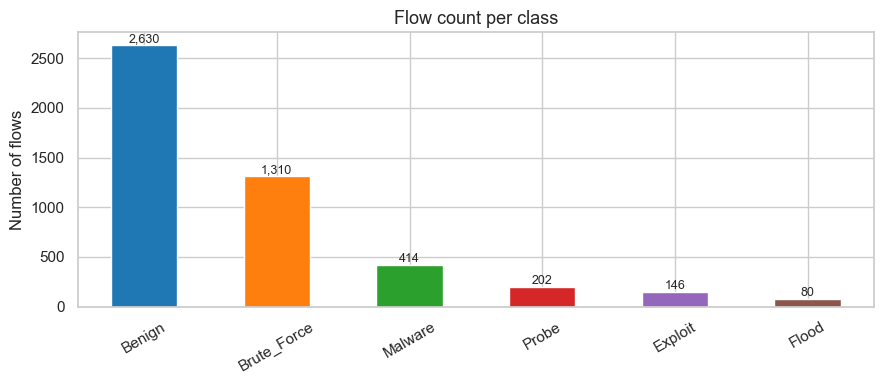

In [8]:
# Flow count per class
flow_counts = features['label'].value_counts()

fig, ax = plt.subplots(figsize=(9, 4))
flow_counts.plot(kind='bar', ax=ax, color=sns.color_palette('tab10', len(flow_counts)))
ax.set_title('Flow count per class', fontsize=13)
ax.set_xlabel(''); ax.set_ylabel('Number of flows')
ax.tick_params(axis='x', rotation=30)
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}',
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig(DATA_DIR / 'plots' / '08_flow_count_per_class.png', dpi=150)
plt.show()

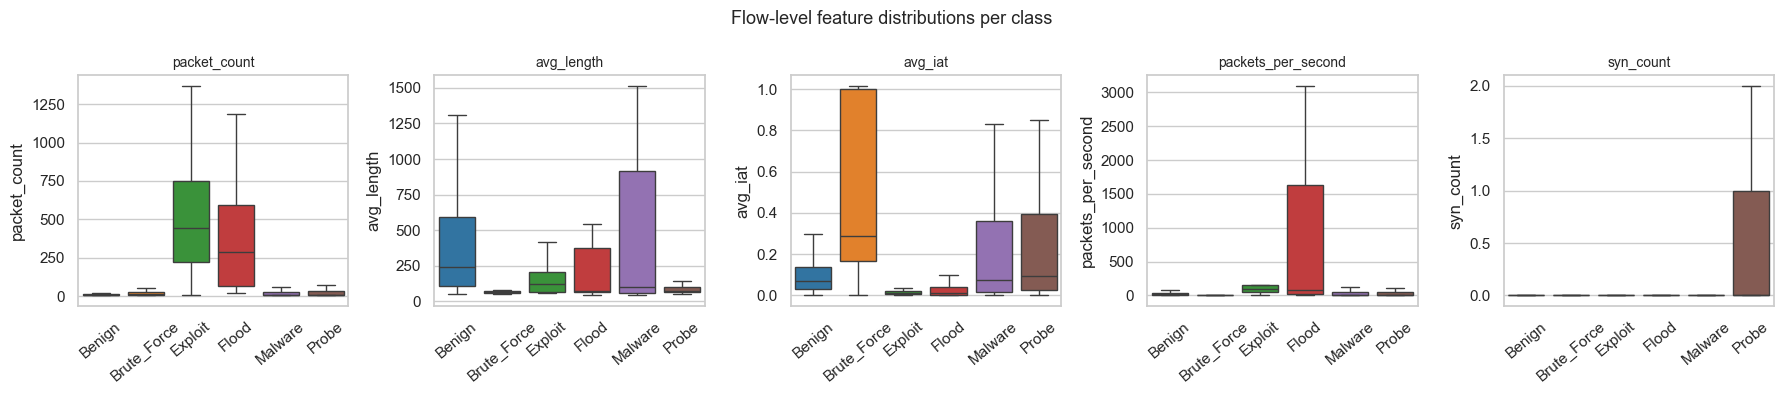

In [9]:
# Key feature distributions per class
key_features = ['packet_count', 'avg_length', 'avg_iat', 'packets_per_second', 'syn_count']

fig, axes = plt.subplots(1, len(key_features), figsize=(18, 4))

for ax, feat in zip(axes, key_features):
    sns.boxplot(data=features, x='label', y=feat,
                palette='tab10', showfliers=False, ax=ax)
    ax.set_title(feat, fontsize=10)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=40)

plt.suptitle('Flow-level feature distributions per class', fontsize=13)
plt.tight_layout()
plt.savefig(DATA_DIR / 'plots' / '09_flow_feature_boxplots.png', dpi=150)
plt.show()

## 6. Save features to Parquet

In [10]:
out_path = DATA_DIR / 'features.parquet'
features.to_parquet(out_path, index=False)
size_mb = out_path.stat().st_size / 1e6
print(f'Saved {len(features):,} flows to {out_path}  ({size_mb:.2f} MB)')
print(f'Columns saved: {features.columns.tolist()}')

Saved 4,782 flows to data\features.parquet  (0.23 MB)
Columns saved: ['flow_id', 'packet_count', 'avg_length', 'std_length', 'min_length', 'max_length', 'avg_iat', 'std_iat', 'duration', 'bytes_per_second', 'packets_per_second', 'syn_count', 'ack_count', 'fin_count', 'rst_count', 'http_request_count', 'http_response_count', 'unique_dst_ports', 'protocol_encoded', 'label', 'src_file']


## ✅ Notebook 3 complete
**Output:** `data/features.parquet`  
Each row = one network flow with 18 statistical features + label.  
**Next:** Run `04_model_training.ipynb`